In [1]:
import cafe
import scanpy as sc

cafe.settings.backend = "python_function"
cafe.logger.setLevel("INFO")

[2025年07月08日 17时54分17秒] INFO                                                                                 
                                          _____     _ _ ______    _       ______            _                      
                                         / ____|   | | |  ____|  | |     |  ____|          | |                     
                                        | |     ___| | | |__ __ _| |_ ___| |__  __  ___ __ | | ___  _ __ ___ _ __  
                                        | |    / _ \ | |  __/ _` | __/ _ \  __| \ \/ / '_ \| |/ _ \| '__/ _ \ '__| 
                                        | |___|  __/ | | | | (_| | ||  __/ |____ >  <| |_) | | (_) | | |  __/ |    
                                         \_____\___|_|_|_|  \__,_|\__\___|______/_/\_\ .__/|_|\___/|_|  \___|_|    
                                                                                     | |                           
                                                                              

数据

In [2]:
# 读取scvelo的pancreas数据
adata = sc.read_h5ad("../tests/data/bifurcating.h5ad")
# sc.pp.subsample(adata, n_obs=100)
fadata = cafe.data.FateAnnData.from_anndata(adata)
fadata.layers["expression"] = fadata.layers["spliced"]
fadata.layers["count"] = fadata.layers["spliced"]

basis = "umap"
fadata.obs.index = [f"cell_{i:03d}" for i in range(fadata.shape[0])]

fadata

AnnData object with n_obs × n_vars = 1000 × 250
    obs: 'cell_id', 'from', 'to', 'time', 'lineage', 'global_time', 'lin_time_sC -> sEndC', 'lin_time_sA -> sB', 'lin_time_sB -> sBmid', 'lin_time_sBmid -> sC', 'lin_time_sD -> sEndD', 'lin_time_sBmid -> sD'
    uns: 'endpoints', 'gt_velocities', 'lineage_colors', 'startpoints', 'cfe'
    obsm: 'X_emb', 'X_umap'
    layers: 'spliced', 'unspliced', 'expression', 'count'

In [3]:
import pandas as pd

# 手动添加参考里程碑
milestone_network = pd.DataFrame(
    data=[
        ["sA -> sB", "sB -> sBmid"],
        ["sB -> sBmid", "sBmid -> sC"],
        ["sB -> sBmid", "sBmid -> sD"],
        ["sBmid -> sC", "sC -> sEndC"],
        ["sBmid -> sD", "sD -> sEndD"],
    ],
    columns=["from", "to"],
)

fadata.add_trajectory_mannually(milestone_network, cluster_key="lineage")

AnnData object with n_obs × n_vars = 1000 × 250
    obs: 'cell_id', 'from', 'to', 'time', 'lineage', 'global_time', 'lin_time_sC -> sEndC', 'lin_time_sA -> sB', 'lin_time_sB -> sBmid', 'lin_time_sBmid -> sC', 'lin_time_sD -> sEndD', 'lin_time_sBmid -> sD', 'milestone_color', 'milestone'
    uns: 'endpoints', 'gt_velocities', 'lineage_colors', 'startpoints', 'cfe', 'milestone_colors', 'milestone_color_colors', 'milestone_color_dict'
    obsm: 'X_emb', 'X_umap', 'milestone_network_emb'
    layers: 'spliced', 'unspliced', 'expression', 'count'

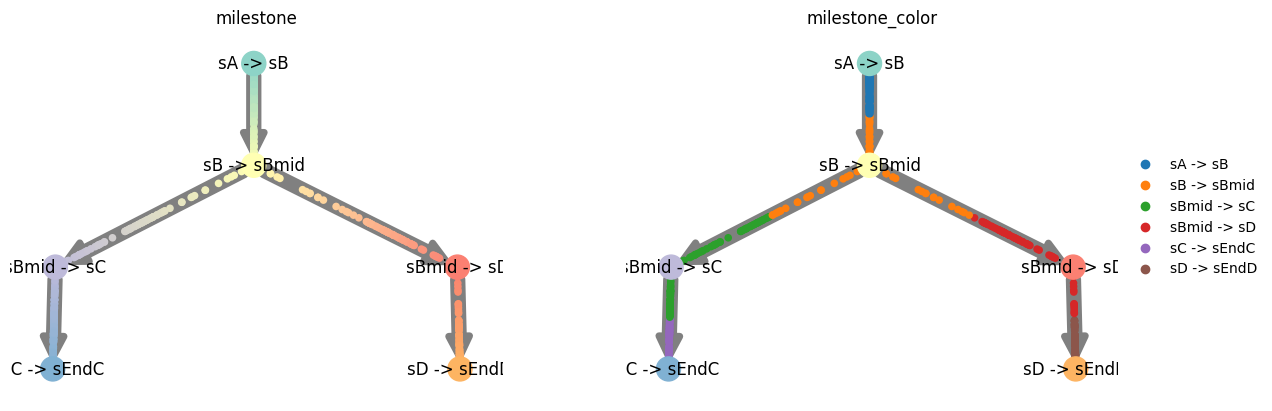

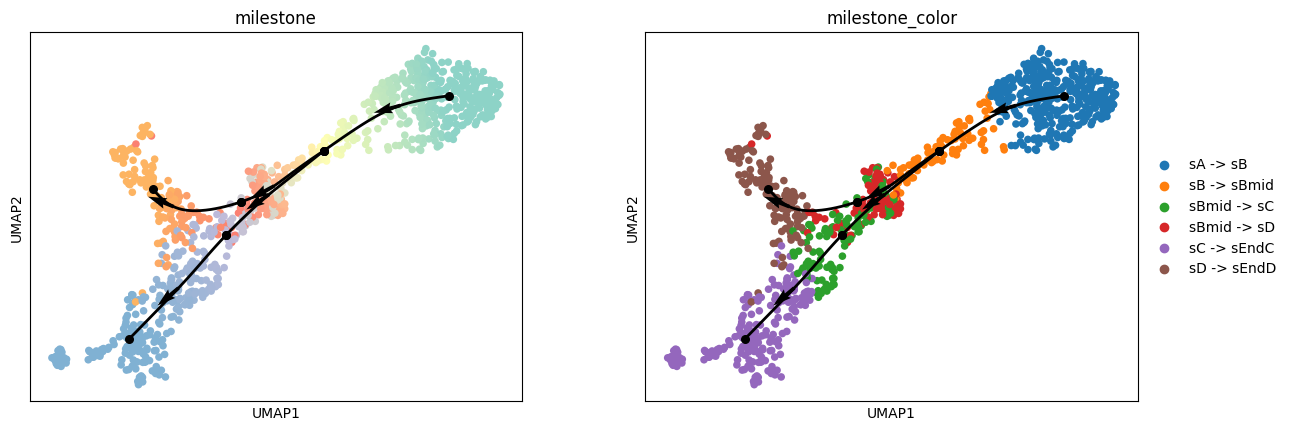

In [4]:
cluster_key = "milestone_color"
fadata.group_onto_nearest_milestones(cluster_key=cluster_key)  # new cluster color

cluster_key_list = ["milestone", cluster_key]
cafe.plot.plot_graph(fadata, color=cluster_key_list)
cafe.plot.plot_trajectory(fadata, basis=basis, color=cluster_key_list)
fadata

## 新绘图函数绘制时会保存到fadata.uns["cfe"]["ref"]["trajectory_embedding"]里, 暂时绘制里程碑网络

<Axes: title={'center': 'milestone_color'}, xlabel='emb1', ylabel='emb2'>

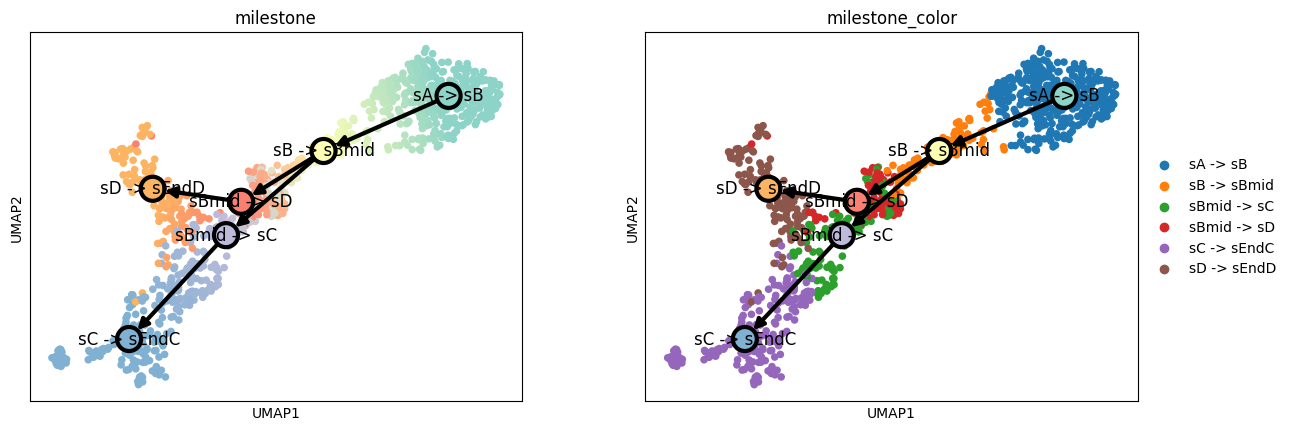

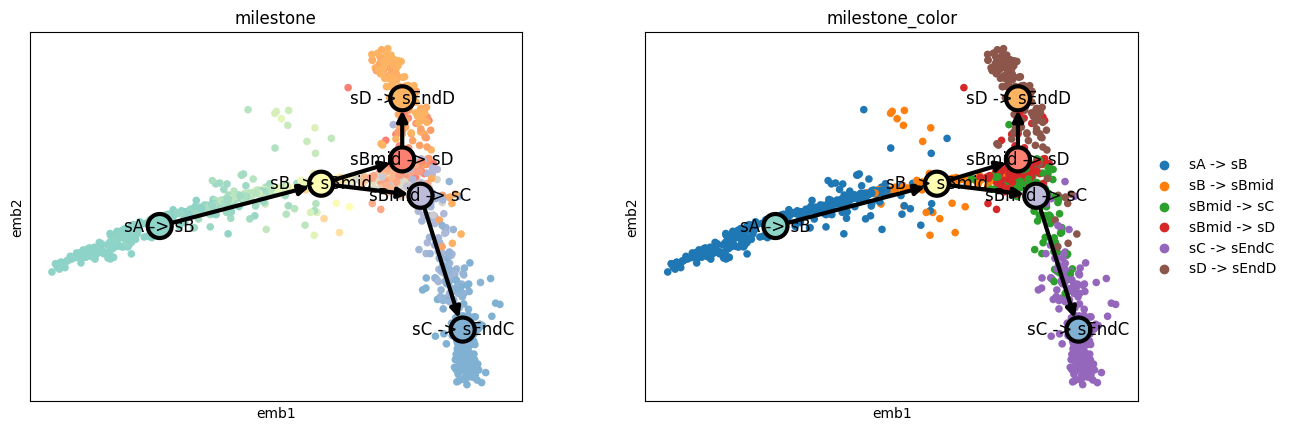

In [5]:
cluster_key = "lineage"
cafe.plot.plot_trajectory_new(fadata, basis="umap", curve=False, color=cluster_key_list)
cafe.plot.plot_trajectory_new(fadata, basis="emb", curve=False, color=cluster_key_list)

## 额外方法结果添加

[2025年07月08日 17时54分38秒] INFO     Loaded function: <function cf_paga at 0x7f87dcbf2950> from                  
                                       /home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/method/functi
                                       on/cf_paga.py                                                               
                        INFO     method_backend: <cafe.method.fate_function_backend.FunctionBackend object at       
                                 0x7f87d6bee170>                                                                   
Normalized count data: X, spliced, unspliced.
Logarithmized X.


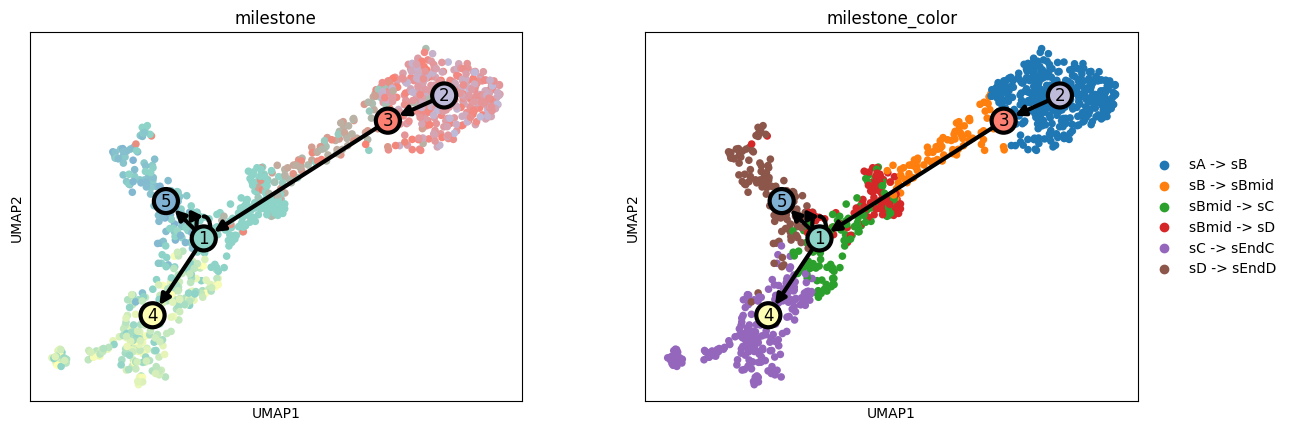

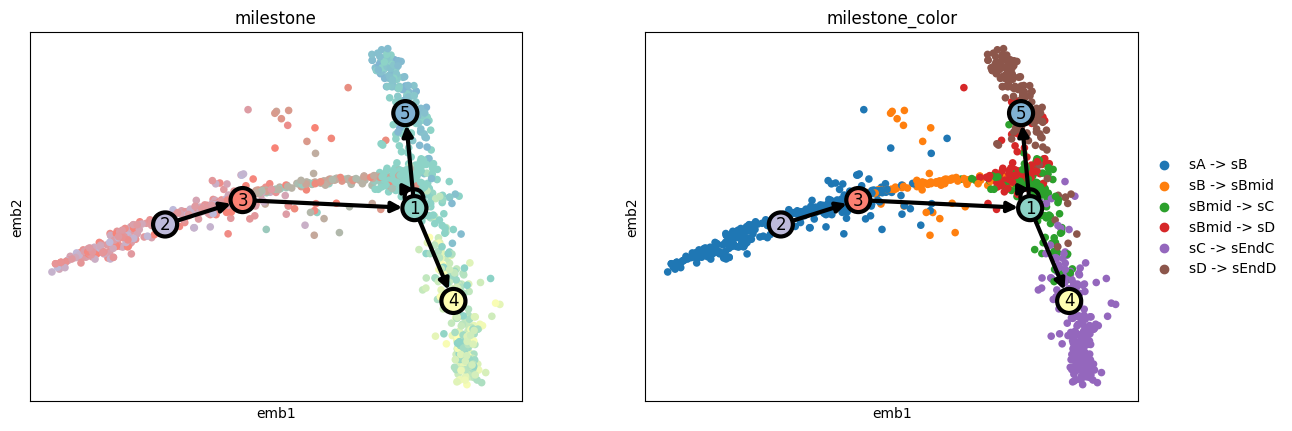

In [6]:
prior_information = {"start_id": fadata.obs.index[0], "groups_id": fadata.obs[cluster_key].tolist()}
parameters = {"filter_features": False, "connectivity_cutoff": 0.3}
fadata.add_prior_information(**prior_information)  # add prior information to fadata


method_name_list = ["paga"]

for method_name in method_name_list:
    method = cafe.method.FateMethod(method_name=method_name)

    method.infer_trajectory(fadata)

    # cafe.plot.plot_trajectory_new(fadata, basis="umap", curve=False, color=cluster_key) 单独cluster_key会出错
    cafe.plot.plot_trajectory_new(fadata, basis="umap", curve=False, color=cluster_key_list)
    cafe.plot.plot_trajectory_new(fadata, basis="emb", curve=False, color=cluster_key_list)

In [8]:
records = {}
for model in fadata.uns["cfe"]["trajectory_history_dict"].keys():
    # 跳过参考自身（ref vs ref）若不想算，可以加 if model=="ref": continue
    print(f"Calculating metrics for model: {model}")
    res = cafe.metric.calculate_metrics(
        fadata,
        now_model=model,
        ref_model="ref",
        simplify=False,  # 是否简化结果
        metrics=["edge_flip", "him"]
    )
    fadata.add_metric(res, model_name=model)

Calculating metrics for model: ref
Calculating metrics for model: 20250708_175438__paga-python_function__lvPuyLJOI9


In [9]:
fadata.uns["cfe"]["trajectory_history_dict"]["ref"]["metric_dict"]

{'edge_flip': 1.0, 'him': 1.0}

In [10]:
fadata.uns["cfe"]["trajectory_history_dict"]["ref"]["milestone_wrapper"]["color_list"]

['#8dd3c7', '#ffffb3', '#bebada', '#fb8072', '#80b1d3', '#fdb462']

In [11]:
fadata.obs = fadata.obs[["lineage", "global_time"]]
fadata.write_h5ad("bifurcating_fadata.h5ad")

transfer milestone color from tuple to list
transfer 'ref' to dict
transfer '20250708_175438__paga-python_function__lvPuyLJOI9' to dict
